In [ ]:
import kagglehub
path = kagglehub.dataset_download("elmadafri/the-wildfire-dataset")

print("Path to dataset files:", path)

In [2]:
#importing necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten, Dense,Dropout,Input

In [3]:
#To ensure the GPU is prsent
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
  tf.config.experimental.set_memory_growth(physical_devices[0], True)
  print("GPU is available")
else:
  print("GPU is not available")

GPU is not available


In [4]:
# Load the dataset
train_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train'
val_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/val'
test_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/test'

In [5]:
#list all the classes
classes=os.listdir(test_dir)
num_classes=len(classes)

#display the class names
print(f'Number of classes: {num_classes}')
print(f'Classes: {classes}')

Number of classes: 2
Classes: ['nofire', 'fire']


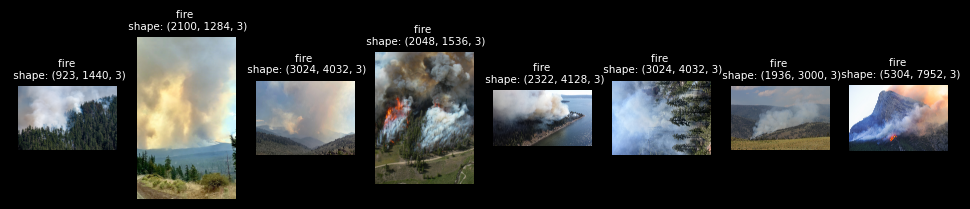

In [6]:
#visulize the images  of fire
plt.style.use('dark_background')
plt.figure(figsize=(12,10))
for i in range(8):
  class_path=os.path.join(train_dir,classes[1])
  img_name=os.listdir(class_path)[i]
  img_path=os.path.join(class_path,img_name)
  img=plt.imread(img_path)

  plt.subplot(1,8,i+1)
  plt.imshow(img)
  plt.title(f'{classes[1]} \n shape: {img.shape}', fontsize=7.5)

  plt.axis('off')
plt.show()

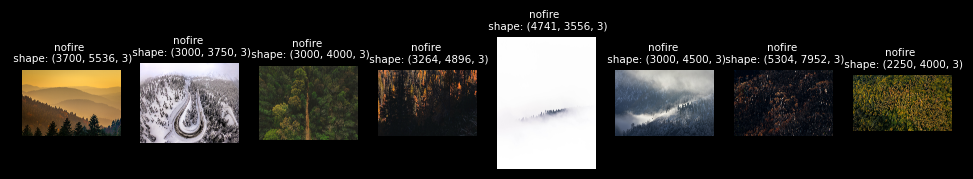

In [7]:
#visulization of no fire
plt.style.use('dark_background')
plt.figure(figsize=(12,10))
for i in range(8):
  class_path=os.path.join(train_dir,classes[0])
  img_name=os.listdir(class_path)[i]
  img_path=os.path.join(class_path,img_name)
  img=plt.imread(img_path)
  plt.subplot(1,8,i+1)
  plt.imshow(img)
  plt.title(f'{classes[0]} \n shape: {img.shape}', fontsize=7.5)
  plt.axis('off')
plt.show()

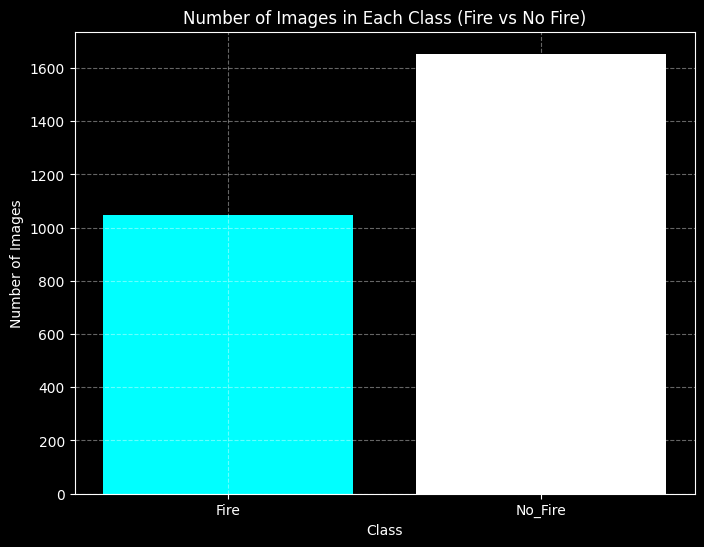

In [8]:
plt.style.use('dark_background')
base_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version'
splits = ['train', 'val', 'test']
class_counts = {'Fire': 1, 'No_Fire': 0}

for split in splits:
    split_dir = os.path.join(base_dir, split)
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        count = len(os.listdir(cls_path))
        if cls.lower() == 'fire':
            class_counts['Fire'] += count
        elif cls.lower() == 'nofire':
            class_counts['No_Fire'] += count
plt.figure(figsize=(8,6))
plt.bar(class_counts.keys(), class_counts.values(), color=['cyan', 'white'])
plt.title('Number of Images in Each Class (Fire vs No Fire)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

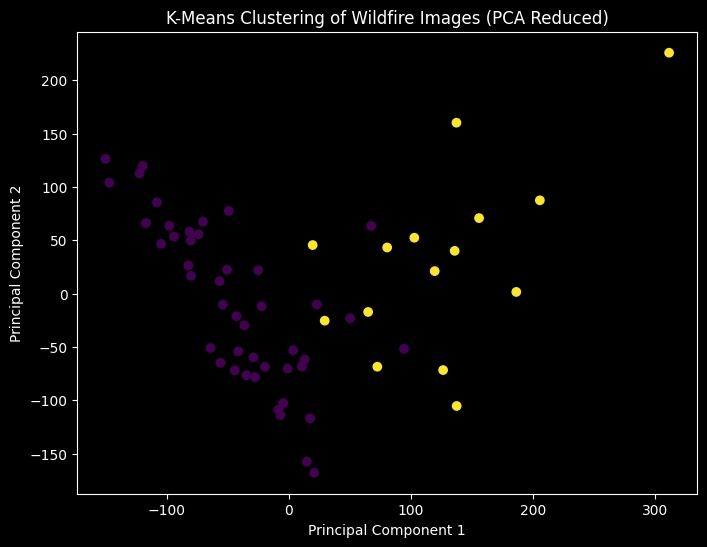

In [40]:
#Apply clustering
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

feature_extractor = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
feature_extractor.trainable = False

def extract_image_features(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    processed_img = preprocess_input(img_array)
    features = feature_extractor.predict(processed_img)
    return features.flatten()


classes = ['nofire', 'fire']
image_features = []
labels = []
num_images_per_class = 30

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)[:num_images_per_class]
    for img_name in image_names:
        img_path = os.path.join(class_path, img_name)
        features = extract_image_features(img_path)
        image_features.append(features)
        labels.append(class_name)

image_features = np.array(image_features)
labels = np.array(labels)


num_clusters = 2
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(image_features)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(image_features)
plt.figure(figsize=(8, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=cluster_labels, cmap='viridis')
plt.title('K-Means Clustering of Wildfire Images (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [35]:
IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    shuffle = True
)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)



Found 1887 images belonging to 2 classes.
Found 1887 images belonging to 2 classes.
Found 402 images belonging to 2 classes.
Found 410 images belonging to 2 classes.


In [36]:
class_mapping=train_generator.class_indices
print(class_mapping)
class_names=list(class_mapping.keys())
print("class names:",class_names)

{'fire': 0, 'nofire': 1}
class names: ['fire', 'nofire']


In [37]:
print("Before training the model .\n")
print(f"Training on {train_generator.samples} images, validating on {val_generator.samples} images.")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}, Batch size: {BATCH_SIZE}")
print(f"Number of classes: {train_generator.num_classes}")



Before training the model .

Training on 1887 images, validating on 402 images.
Image size: 150x150, Batch size: 32
Number of classes: 2


In [38]:
# Let's build the CNN Model
model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
]
)


In [39]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# train the model
history = model.fit(
    train_generator,
    steps_per_epoch = train_generator.samples //BATCH_SIZE,
    epochs = 30,
    validation_data = val_generator,
    validation_steps = val_generator.samples // BATCH_SIZE
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
27/58 ━━━━━━━━━━━━━━━━━━━━ 4:57 10s/step - accuracy: 0.5699 - loss: 0.9456

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


53/58 ━━━━━━━━━━━━━━━━━━━━ 48s 10s/step - accuracy: 0.6087 - loss: 0.8216

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


58/58 ━━━━━━━━━━━━━━━━━━━━ 689s 12s/step - accuracy: 0.6137 - loss: 0.8048 - val_accuracy: 0.7109 - val_loss: 0.5164
Epoch 2/30
 1/58 ━━━━━━━━━━━━━━━━━━━━ 3:24 4s/step - accuracy: 0.7500 - loss: 0.5598

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


58/58 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.7500 - loss: 0.5598 - val_accuracy: 0.7422 - val_loss: 0.5047
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 733s 12s/step - accuracy: 0.7467 - loss: 0.5275 - val_accuracy: 0.7604 - val_loss: 0.4622
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.8438 - loss: 0.5042 - val_accuracy: 0.7448 - val_loss: 0.4748
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 677s 12s/step - accuracy: 0.7749 - loss: 0.4543 - val_accuracy: 0.7839 - val_loss: 0.4358
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.7500 - loss: 0.4574 - val_accuracy: 0.7630 - val_loss: 0.4428
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 682s 12s/step - accuracy: 0.7857 - loss: 0.4464 - val_accuracy: 0.7839 - val_loss: 0.4396
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.7188 - loss: 0.5136 - val_accuracy: 0.7734 - val_loss: 0.4399
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 705s 12s/step - accuracy: 0.7884 - loss: 0.4312 - val_accuracy: 0.8073 - val_loss

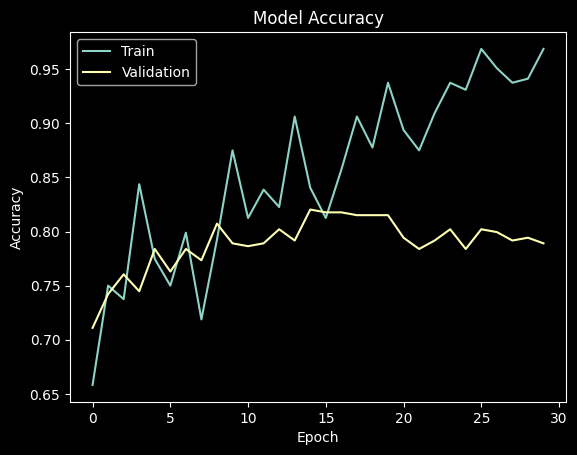

In [16]:
#Evaluate the model -plotting training and validation.accuarcy
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'],loc='upper left')
plt.show()

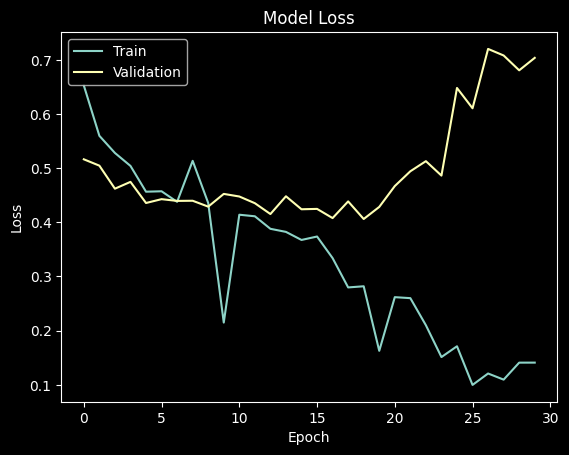

In [17]:
#Evaluate the model -plotting training and validation loss
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper left')
plt.show()

In [18]:
#Evaluate the model using test data
test_loss,test_acc=model.evaluate(test_generator,steps=test_generator.samples//BATCH_SIZE)
print(f'Test Accuracy: {test_acc:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.6622 - loss: 1.0568
Test Accuracy: 0.7500


162/411 ━━━━━━━━━━━━━━━━━━━━ 51s 206ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


163/411 ━━━━━━━━━━━━━━━━━━━━ 53s 217ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


192/411 ━━━━━━━━━━━━━━━━━━━━ 52s 240ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


411/411 ━━━━━━━━━━━━━━━━━━━━ 126s 305ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


<Figure size 600x500 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


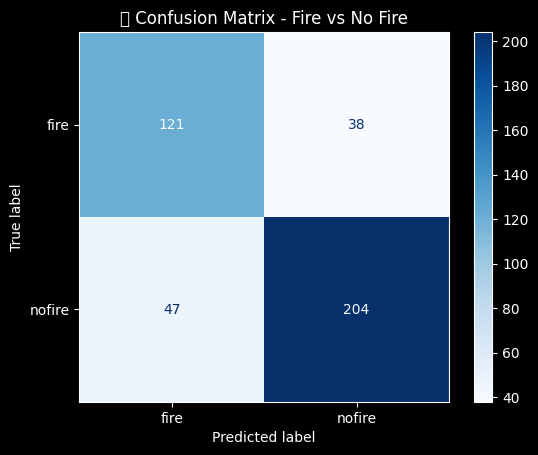

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

test_generator.reset()

pred_probs = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
pred_classes = (pred_probs > 0.5).astype(int).reshape(-1)

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)
labels = list(test_generator.class_indices.keys())


plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("📊 Confusion Matrix - Fire vs No Fire")
plt.grid(False)
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


161/411 ━━━━━━━━━━━━━━━━━━━━ 50s 203ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


162/411 ━━━━━━━━━━━━━━━━━━━━ 50s 204ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


191/411 ━━━━━━━━━━━━━━━━━━━━ 49s 225ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


411/411 ━━━━━━━━━━━━━━━━━━━━ 122s 294ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


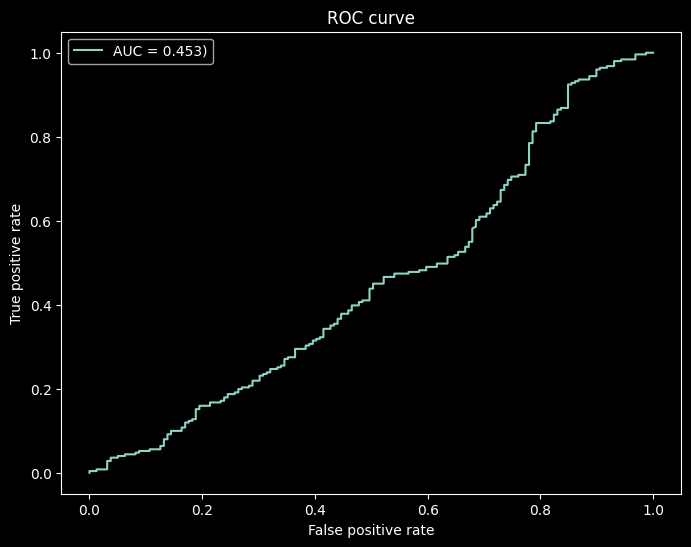

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

test_generator.reset()
y_pred_keras = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1).ravel()
fpr, tpr, thresholds_keras = roc_curve(test_generator.classes, y_pred_keras)
auc_keras = roc_auc_score(test_generator.classes, y_pred_keras)

plt.figure(1, figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='AUC = {:.3f})'.format(auc_keras))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

In [32]:
from sklearn.metrics import classification_report

print("📄 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=test_generator.class_indices.keys()))


📄 Classification Report:
              precision    recall  f1-score   support

        fire       0.72      0.76      0.74       159
      nofire       0.84      0.81      0.83       251

    accuracy                           0.79       410
   macro avg       0.78      0.79      0.78       410
weighted avg       0.80      0.79      0.79       410



162/411 ━━━━━━━━━━━━━━━━━━━━ 44s 177ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


191/411 ━━━━━━━━━━━━━━━━━━━━ 45s 207ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


411/411 ━━━━━━━━━━━━━━━━━━━━ 118s 283ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


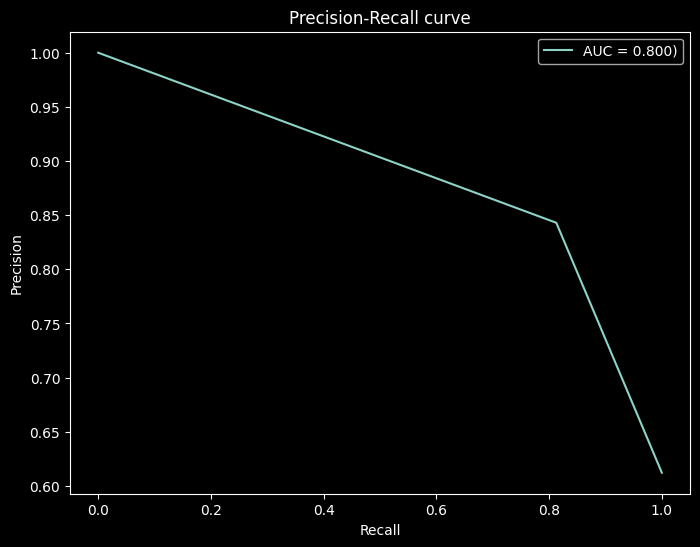

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_pred_keras = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
y_pred_keras = (y_pred_keras > 0.5).astype(int).reshape(-1)
precision, recall, thresholds_pr = precision_recall_curve(test_generator.classes, y_pred_keras)
auc_pr = average_precision_score(test_generator.classes, y_pred_keras)

plt.figure(1, figsize=(8, 6))
plt.plot(recall, precision, label='AUC = {:.3f})'.format(auc_pr))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend(loc='best')
plt.show()

In [21]:
#save the model
model.save('FFD.keras')

In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


#predict on new image -create a function
def predict_fire(img_path):
  img=image.load_img(img_path,target_size=(150,150))
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array/=255.0

  prediction=model.predict(img_array)
  if prediction[0] > 0.5:
    predicted_class = class_names[1]
  else:
    predicted_class = class_names[0]

  plt.imshow(img)
  plt.title(f'Predicted: {predicted_class}')
  plt.axis('off')
  plt.show()





In [23]:
os.listdir('/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/nofire')


['josh-sorenson-w_QAjcf1ipU-unsplash.jpg',
 'balazs-busznyak-AhMSy4GpU0w-unsplash.jpg',
 '52358616216_ec885ff145_o.jpg',
 'matthias-heil-T7lMR-syZAg-unsplash.jpg',
 'mark-boss-KG8N1Rqf02w-unsplash.jpg',
 'chris-barbalis-SIbpq4Lvzdk-unsplash.jpg',
 'brendan-beale-h3qe4EZd4_4-unsplash.jpg',
 'dan-rogers-G807nWEuFIo-unsplash.jpg',
 'hala-alghanim-yyE90v_E8dA-unsplash.jpg',
 'zetong-li-79sabz_JrXg-unsplash.jpg',
 'federico-bottos-JUFuI-kBtas-unsplash.jpg',
 'single-earth-FP5tOXT6aMs-unsplash.jpg',
 'sunnie-KJ_G43MHDf0-unsplash.jpg',
 '35581707273_fed23248e8_o.jpg',
 'martin-sanchez-ML6kHR--Uys-unsplash.jpg',
 'marek-piwnicki-DCGABYDIdT0-unsplash.jpg',
 'austin-schmid-zQ-y4Gj8194-unsplash.jpg',
 'rhema-kallianpur-t0GpJ2cdJuo-unsplash.jpg',
 'victor-rodriguez-e5g9otcYzkU-unsplash.jpg',
 'kristaps-ungurs-7aY6JOyFY8A-unsplash.jpg',
 '52452040025_916ddf3f9d_o.jpg',
 'daniil-silantev-VggwSJxYlAw-unsplash.jpg',
 'josh-withers-UN_W3z4D0pw-unsplash.jpg',
 'dave-hoefler-swH_IVJGLDA-unsplash.jpg',
 '

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


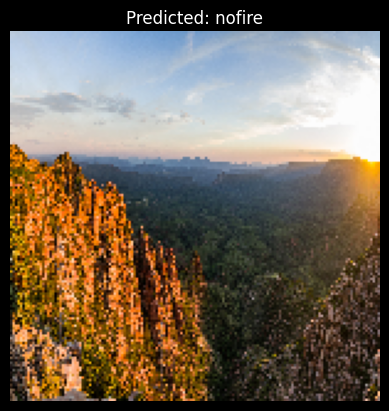

In [24]:
predict_fire('/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/nofire/35554264024_b33afa21ac_o.jpg')
